In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving area.csv to area (2).csv


In [ ]:
#Linear Regression

In [ ]:
#Step 1 Imports
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import statsmodels.api as sm



In [ ]:
# Step 2 loading the data
df = pd.read_csv('area.csv')

In [ ]:
# Step 3 Data preprocessing
# focusing on country-level data (excluding continents/regions)
# First ensuring the 'Code' column is treated as strings
df['Code'] = df['Code'].astype(str)
countries = df[~df['Code'].isna() & ~df['Code'].str.startswith('OWID')]


In [ ]:
# Checking for missing values
print("Missing values check:")
print(f"Years missing: {df['Year'].isna().sum()}")
print(f"Area values missing: {df['Annual area burnt by wildfires'].isna().sum()}")


Missing values check:
Years missing: 0
Area values missing: 0


In [ ]:
# Step 4 Feature engineering - we'll use Year as the feature to predict area burnt
# Selecting features and target
X = df[['Year']]
y = df['Annual area burnt by wildfires']



In [ ]:
# Verify shapes before splitting
print("\nData shapes:")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Data shapes:
Features shape: (3354, 1)
Target shape: (3354,)


In [ ]:
# Fitting the model
model = sm.OLS(y, X).fit()

# Printing OLS summary report
print(model.summary())

                                       OLS Regression Results                                      
Dep. Variable:     Annual area burnt by wildfires   R-squared (uncentered):                   0.023
Model:                                        OLS   Adj. R-squared (uncentered):              0.023
Method:                             Least Squares   F-statistic:                              78.32
Date:                            Wed, 16 Jul 2025   Prob (F-statistic):                    1.39e-18
Time:                                    14:23:56   Log-Likelihood:                         -62341.
No. Observations:                            3354   AIC:                                  1.247e+05
Df Residuals:                                3353   BIC:                                  1.247e+05
Df Model:                                       1                                                  
Covariance Type:                        nonrobust                                                  


In [ ]:
#Step 5 Spliting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTrain/test split shapes:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


Train/test split shapes:
X_train: (2683, 1), X_test: (671, 1)
y_train: (2683,), y_test: (671,)


In [ ]:
# Step 6 Initializing and training the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Making predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f"Model Evaluation:")
print(f"Mean Squared Error: {mse:,.2f}")
print(f"R-squared: {r2:.2f}")

Model Evaluation:
Mean Squared Error: 1,470,962,911,479,423.25
R-squared: -0.00


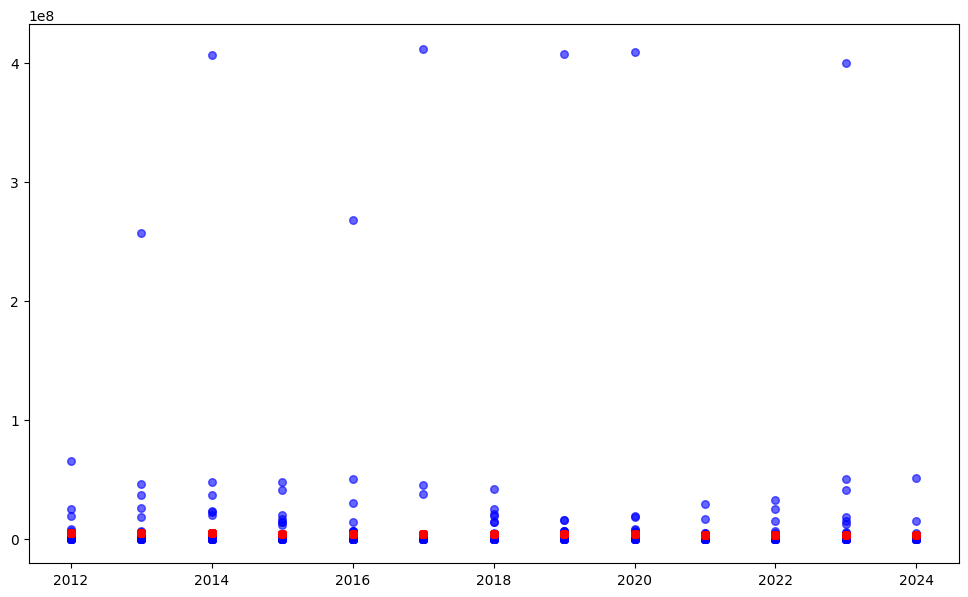

In [ ]:
# Step 7 Plotting actual vs predicted values
# Plot results
plt.figure(figsize=(12, 7))

x_vals = X_test['Year'].values
y_actual = y_test.values
y_pred = np.array(y_pred)

plt.scatter(x_vals, y_actual, color='blue', label='Actual', alpha=0.6, s=30)
plt.scatter(x_vals, y_pred, color='red', label='Predicted', alpha=0.6, s=30)



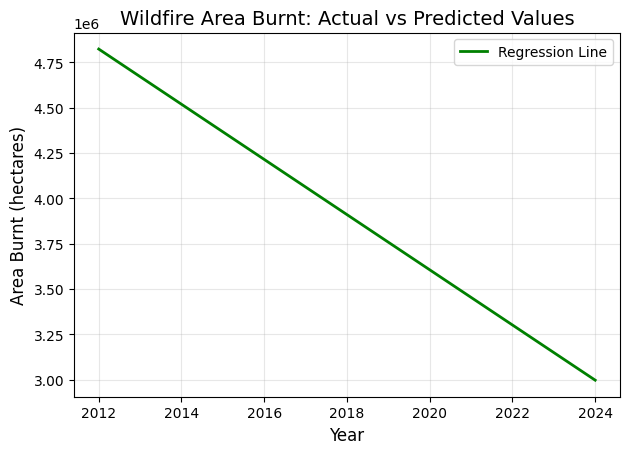

In [ ]:
# Sort values for line plot
sorted_idx = np.argsort(x_vals)
plt.plot(x_vals[sorted_idx], y_pred[sorted_idx], color='green', linewidth=2, label='Regression Line')

plt.title('Wildfire Area Burnt: Actual vs Predicted Values', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Area Burnt (hectares)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# Print model coefficients
print(f"\nModel coefficients:")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Year coefficient: {model.coef_[0]:.2f}")


Model coefficients:
Intercept: 311002873.36
Year coefficient: -152176.68


In [ ]:
# Predict for future years
future_years = np.array([[2025], [2030], [2035]]).reshape(-1, 1)
future_predictions = model.predict(future_years)

print("\nFuture Predictions:")
for year, pred in zip(future_years.flatten(), future_predictions):
    print(f"Year {year}: {pred:,.0f} hectares predicted")


Future Predictions:
Year 2025: 2,845,090 hectares predicted
Year 2030: 2,084,207 hectares predicted
Year 2035: 1,323,323 hectares predicted


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Creating a binary target variable (1 for high wildfire area, 0 for low)
# Using median as threshold
median_area = df['Annual area burnt by wildfires'].median()
df['High_Risk'] = np.where(df['Annual area burnt by wildfires'] > median_area, 1, 0)

In [ ]:
# Feature engineering - using year as a feature[Phython Preprocessing]
X = df[['Year']]
y = df['High_Risk']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Training Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predictions
y_pred = rf.predict(X_test)

In [ ]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.48
Confusion Matrix:
[[257 235]
 [293 222]]


In [ ]:
#Parallel Computing

In [ ]:
#Step 1 Imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import sum


In [ ]:
#Step 2 Spark preprocessing
# Starting Spark session
spark = SparkSession.builder.appName("WildfireAnalysis").getOrCreate()

In [ ]:
# Loading CSV file into a Spark DataFrame
df = spark.read.csv("area.csv", header=True, inferSchema=True)


In [ ]:
#Step 3 Filtering out rows where 'Annual area burnt by wildfires' is null
df_cleaned = df.filter(df["Annual area burnt by wildfires"].isNotNull())
# Grouping by 'Entity' (country) and sum total area burnt
result = df_cleaned.groupBy("Entity").agg(
    sum("Annual area burnt by wildfires").alias("Total_Area_Burnt")
)

In [ ]:
#Step 4 Previewing schema to understand columns
df.printSchema()

root
 |-- Entity: string (nullable = true)
 |-- Code: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Annual area burnt by wildfires: integer (nullable = true)



In [ ]:
# Step 5 Show result
result.show(truncate=False)

+---------------------------------+----------------+
|Entity                           |Total_Area_Burnt|
+---------------------------------+----------------+
|Chad                             |65649459        |
|Anguilla                         |0               |
|Paraguay                         |39360360        |
|Russia                           |181961523       |
|Macao                            |0               |
|Heard Island and McDonald Islands|0               |
|British Indian Ocean Territory   |0               |
|World                            |4883536160      |
|Yemen                            |10936           |
|Senegal                          |27329894        |
|Sweden                           |89079           |
|Tokelau                          |0               |
|French Southern Territories      |0               |
|Kiribati                         |0               |
|Svalbard and Jan Mayen           |101             |
|Guyana                           |2256645    

In [ ]:
# Step 6 Converting to pandas
pandas_df = df_cleaned.select("Year", "Annual area burnt by wildfires").toPandas()

In [ ]:
#Phython preprocessing
# Step 1 Create binary target
median_area = pandas_df['Annual area burnt by wildfires'].median()
pandas_df['High_Risk'] = np.where(
    pandas_df['Annual area burnt by wildfires'] > median_area, 1, 0
)

In [ ]:
# Step 2 Preparing features/target for ML
X = pandas_df[['Year']]  # Features
y = pandas_df['High_Risk']

In [ ]:
#Step 3 Model Training and evaluation
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)


In [ ]:
#Step 4 Training model
model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

In [ ]:
#Step 5 Making predictions
y_pred = model.predict(X_test)

In [ ]:
#Step 6 Evaluation
print("\n=== Evaluation Metrics ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))




=== Evaluation Metrics ===
Accuracy: 0.48
Confusion Matrix:
[[257 235]
 [293 222]]


In [ ]:
#  Stopping our ML code for Spark
spark.stop()

In [ ]:
#PyTourch for GPU
import torch
import torch.nn as nn
import torch.optim as optim
import time

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Simple Model Example
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(1, 1)

    def forward(self, x):
        return self.fc(x)

# Initialize Model on GPU
model = SimpleModel().to(device)

# Dummy Data (Move to GPU)
X = torch.randn(1000, 1).to(device)
y = torch.randn(1000, 1).to(device)

# Loss & Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Simple Training Loop with Time Check
start = time.time()
for epoch in range(1000):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()
end = time.time()

print(f"Training Time on {device}: {end - start:.4f} seconds")



Using device: cpu
Training Time on cpu: 2.2887 seconds


In [ ]:
#Multipreprocessing
from multiprocessing import Pool, cpu_count
import numpy as np
import time

# Example function to apply on each data point
def process_data(x):
    return x ** 2 + 10

# Create dummy data
data = list(range(1000000))

# Check available CPU cores in Colab
print(f"CPU cores available: {cpu_count()}")

# Multiprocessing pool
start = time.time()
with Pool() as pool:
    result = pool.map(process_data, data)
end = time.time()

print(f"Multiprocessing Time: {end - start:.4f} seconds")


CPU cores available: 2
Multiprocessing Time: 0.7362 seconds


In [ ]:
#Comparision by matrix
import torch
import time

# Matrix Size
matrix_size = 10000

# CPU Matrix Multiplication
A_cpu = torch.randn(matrix_size, matrix_size)
B_cpu = torch.randn(matrix_size, matrix_size)

start = time.time()
result_cpu = torch.mm(A_cpu, B_cpu)
cpu_time = time.time() - start
print(f"CPU Matrix Multiplication Time: {cpu_time:.4f} sec")

# GPU Matrix Multiplication
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
A_gpu = torch.randn(matrix_size, matrix_size, device=device)
B_gpu = torch.randn(matrix_size, matrix_size, device=device)

start = time.time()
result_gpu = torch.mm(A_gpu, B_gpu)
torch.cuda.synchronize()  # Wait for GPU ops to finish
gpu_time = time.time() - start
print(f"GPU Matrix Multiplication Time: {gpu_time:.4f} sec")


CPU Matrix Multiplication Time: 27.5797 sec
GPU Matrix Multiplication Time: 0.6885 sec


In [ ]:
# Comparision by Accuarcy

class SimpleModel(torch.nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = torch.nn.Linear(10, 1)

    def forward(self, x):
        return self.fc(x)

def train_model(device):
    X = torch.randn(10000, 10).to(device)
    y = torch.randn(10000, 1).to(device)
    model = SimpleModel().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    loss_fn = torch.nn.MSELoss()

    start = time.time()
    for epoch in range(100):
        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
    torch.cuda.synchronize() if device.type == 'cuda' else None
    end = time.time()
    return end - start, loss.item()

# CPU Training
cpu_time, cpu_loss = train_model(torch.device('cpu'))
print(f"CPU Training Time: {cpu_time:.4f} sec | Loss: {cpu_loss:.4f}")

# GPU Training
if torch.cuda.is_available():
    gpu_time, gpu_loss = train_model(torch.device('cuda'))
    print(f"GPU Training Time: {gpu_time:.4f} sec | Loss: {gpu_loss:.4f}")


CPU Training Time: 0.0975 sec | Loss: 1.0379
GPU Training Time: 0.3505 sec | Loss: 1.0198


In [ ]:
#Comparision by Training Time
from multiprocessing import Pool

# Random heavy function
def heavy_computation(x):
    return x ** 2 + x ** 3

data = list(range(1000000))

# Normal (Single Core)
start = time.time()
result_normal = [heavy_computation(x) for x in data]
normal_time = time.time() - start
print(f"Normal Single Core Time: {normal_time:.4f} sec")

# Multiprocessing (Parallel)
start = time.time()
with Pool() as pool:
    result_parallel = pool.map(heavy_computation, data)
parallel_time = time.time() - start
print(f"Multiprocessing Time: {parallel_time:.4f} sec")


Normal Single Core Time: 0.2074 sec
Multiprocessing Time: 0.8350 sec
